In [98]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================
import os
import random
import shutil
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import io
from rembg import remove

from torch.utils.data import (
    DataLoader,
    Dataset,
    random_split
)

from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.11.0+cu128
Device: cuda


In [99]:
# ============================================================
# CELL: INSTALL EXTRA PACKAGES (background removal)
# ============================================================
!pip install -q rembg onnxruntime

In [100]:
# ============================================================
# CELL 2: REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [101]:
# ============================================================
# CELL 3: CLONE GITHUB REPOSITORY
# ============================================================

GITHUB_REPO = "https://github.com/Mehedi752/CNN-Project"

!git clone $GITHUB_REPO

%cd CNN-Project
!git pull origin main
%cd ..

REPO_NAME = "CNN-Project"
REPO_PATH = f"/content/{REPO_NAME}"

CUSTOM_DATA_PATH = f"{REPO_PATH}/datasets"
MODEL_DIR = f"{REPO_PATH}/model"

os.makedirs(MODEL_DIR, exist_ok=True)

print("Repository:", REPO_PATH)
print("Custom dataset:", CUSTOM_DATA_PATH)

fatal: destination path 'CNN-Project' already exists and is not an empty directory.
/content/CNN-Project
From https://github.com/Mehedi752/CNN-Project
 * branch            main       -> FETCH_HEAD
Already up to date.
/content
Repository: /content/CNN-Project
Custom dataset: /content/CNN-Project/datasets


In [102]:
# ============================================================
# CELL 3b: CHECK IF A TRAINED MODEL ALREADY EXISTS
# ============================================================

BEST_MODEL_PATH = f"{MODEL_DIR}/210137.pth"
FORCE_RETRAIN = False

MODEL_EXISTS = os.path.exists(BEST_MODEL_PATH)
SKIP_TRAINING = MODEL_EXISTS and not FORCE_RETRAIN

if SKIP_TRAINING:
    print(f"Found existing trained model at: {BEST_MODEL_PATH}")
    print("-> Training will be SKIPPED. The saved weights will be loaded instead.")
else:
    print("No existing trained model found (or FORCE_RETRAIN=True).")
    print("-> The model will be trained from scratch in this run.")

Found existing trained model at: /content/CNN-Project/model/210137.pth
-> Training will be SKIPPED. The saved weights will be loaded instead.


In [103]:
# ============================================================
# CELL 4: VERIFY CUSTOM IMAGES
# ============================================================

custom_images = sorted([
    file for file in os.listdir(CUSTOM_DATA_PATH)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Number of custom images:", len(custom_images))

for image in custom_images:
    print(image)

Number of custom images: 10
apple1.jpeg
apple2.jpeg
apple3.jpeg
apple4.jpeg
banana1.jpeg
banana2.jpeg
banana3.jpeg
orange1.jpeg
orange2.jpeg
orange3.jpeg


In [104]:
# ============================================================
# CELL 4b: REMOVE BACKGROUND FROM CUSTOM PHONE PHOTOS
# ============================================================

PROCESSED_DATA_PATH = f"{REPO_PATH}/datasets_processed"
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

def remove_background_to_white(image_path, output_path, canvas_size=(400, 400)):
    with open(image_path, "rb") as f:
        input_bytes = f.read()

    output_bytes = remove(input_bytes)
    foreground = Image.open(io.BytesIO(output_bytes)).convert("RGBA")

    # Crop tightly to the non-transparent (foreground) pixels so the fruit
    # fills the frame the same way Fruits-360 images do.
    alpha = foreground.split()[-1]
    bbox = alpha.getbbox()
    if bbox is not None:
        foreground = foreground.crop(bbox)

    # Paste onto a square white canvas, centered, preserving aspect ratio.
    fg_w, fg_h = foreground.size
    scale = min(canvas_size[0] / fg_w, canvas_size[1] / fg_h) * 0.9
    new_size = (max(1, int(fg_w * scale)), max(1, int(fg_h * scale)))
    foreground = foreground.resize(new_size)

    canvas = Image.new("RGBA", canvas_size, (255, 255, 255, 255))
    paste_pos = (
        (canvas_size[0] - new_size[0]) // 2,
        (canvas_size[1] - new_size[1]) // 2,
    )
    canvas.paste(foreground, paste_pos, foreground)

    canvas.convert("RGB").save(output_path)


for filename in custom_images:
    src = os.path.join(CUSTOM_DATA_PATH, filename)
    dst = os.path.join(PROCESSED_DATA_PATH, filename)
    remove_background_to_white(src, dst)

print("Background-removed images saved to:", PROCESSED_DATA_PATH)


Background-removed images saved to: /content/CNN-Project/datasets_processed


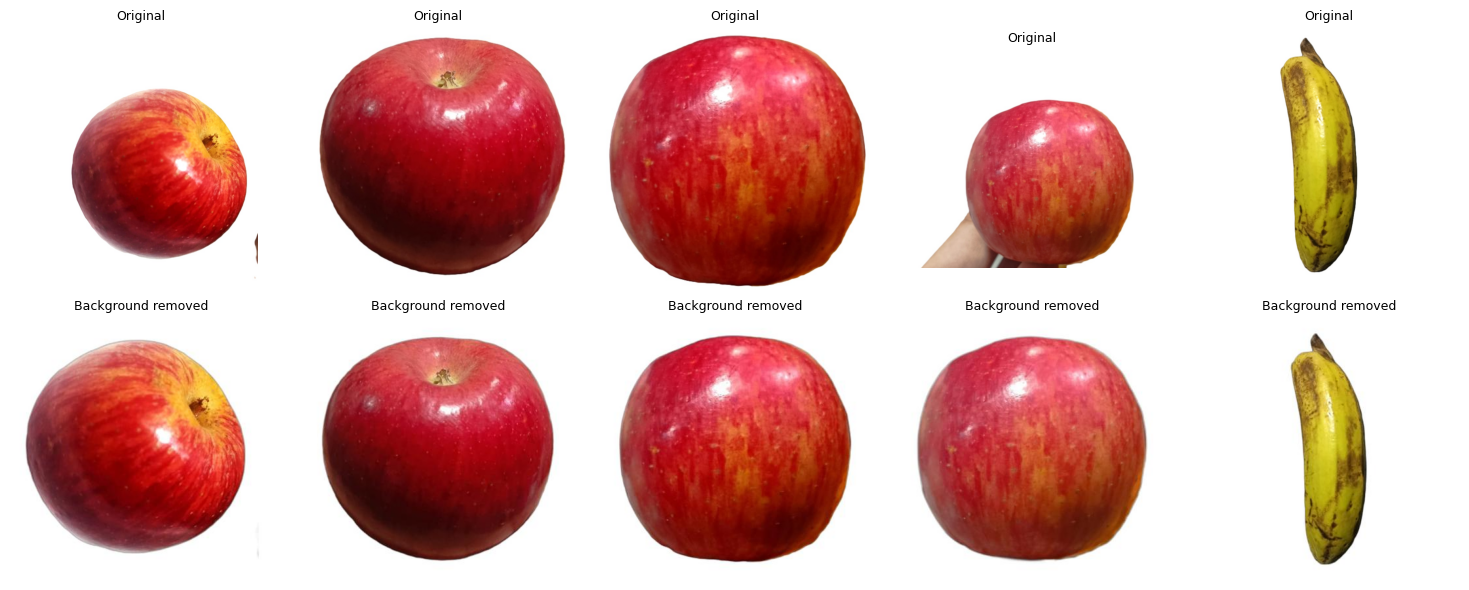

In [105]:
# ============================================================
# CELL 4c: PREVIEW ORIGINAL vs PROCESSED CUSTOM PHOTOS
# ============================================================

preview_n = min(5, len(custom_images))
fig, axes = plt.subplots(2, preview_n, figsize=(3 * preview_n, 6))

for i, filename in enumerate(custom_images[:preview_n]):
    original = Image.open(os.path.join(CUSTOM_DATA_PATH, filename)).convert("RGB")
    processed = Image.open(os.path.join(PROCESSED_DATA_PATH, filename)).convert("RGB")

    axes[0, i].imshow(original)
    axes[0, i].set_title("Original", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(processed)
    axes[1, i].set_title("Background removed", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [106]:
# ============================================================
# CELL 5: DOWNLOAD FRUITS 360
# ============================================================

FRUIT_URL = "https://github.com/Horea94/Fruit-Images-Dataset/archive/refs/heads/master.zip"

ZIP_PATH = "/content/fruits360.zip"
FRUIT_ROOT = "/content/Fruit-Images-Dataset-master"

if not os.path.exists(FRUIT_ROOT):
    print("Downloading Fruits 360 dataset...")

    urllib.request.urlretrieve(
        FRUIT_URL,
        ZIP_PATH
    )

    print("Download completed.")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall("/content")

    print("Dataset extracted.")
else:
    print("Dataset already exists.")

Dataset already exists.


In [107]:
# ============================================================
# CELL 6: LOCATE DATASET DIRECTORIES
# ============================================================

DATASET_ROOT = "/content/Fruit-Images-Dataset-master"

for root, dirs, files in os.walk(DATASET_ROOT):
    if "Training" in root or "Test" in root:
        print(root)

/content/Fruit-Images-Dataset-master/Test
/content/Fruit-Images-Dataset-master/Test/Pineapple
/content/Fruit-Images-Dataset-master/Test/Redcurrant
/content/Fruit-Images-Dataset-master/Test/Passion Fruit
/content/Fruit-Images-Dataset-master/Test/Fig
/content/Fruit-Images-Dataset-master/Test/Cherry Wax Yellow
/content/Fruit-Images-Dataset-master/Test/Cucumber Ripe
/content/Fruit-Images-Dataset-master/Test/Pepper Green
/content/Fruit-Images-Dataset-master/Test/Tomato Yellow
/content/Fruit-Images-Dataset-master/Test/Tangelo
/content/Fruit-Images-Dataset-master/Test/Nectarine
/content/Fruit-Images-Dataset-master/Test/Guava
/content/Fruit-Images-Dataset-master/Test/Onion White
/content/Fruit-Images-Dataset-master/Test/Melon Piel de Sapo
/content/Fruit-Images-Dataset-master/Test/Plum 2
/content/Fruit-Images-Dataset-master/Test/Physalis with Husk
/content/Fruit-Images-Dataset-master/Test/Mangostan
/content/Fruit-Images-Dataset-master/Test/Apple Red Delicious
/content/Fruit-Images-Dataset-maste

In [108]:
# ============================================================
# CELL 7: FIND REQUIRED CLASSES
# ============================================================

TRAINING_ROOT = f"{DATASET_ROOT}/Training"
TEST_ROOT = f"{DATASET_ROOT}/Test"

required_classes = [
    "Apple",
    "Banana",
    "Orange"
]

print("Available matching classes:")

available_classes = []

for class_name in os.listdir(TRAINING_ROOT):
    if (
        class_name.lower().startswith("apple")
        or class_name.lower().startswith("banana")
        or class_name.lower().startswith("orange")
    ):
        available_classes.append(class_name)
        print(class_name)

Available matching classes:
Apple Red Delicious
Apple Pink Lady
Apple Red Yellow 2
Apple Braeburn
Apple Red 2
Apple Golden 2
Apple Crimson Snow
Apple Golden 3
Apple Red Yellow 1
Orange
Apple Red 1
Apple Golden 1
Banana
Banana Red
Banana Lady Finger
Apple Red 3
Apple Granny Smith


In [109]:
# ============================================================
# CELL 8: CREATE 3-CLASS DATASET
# ============================================================

SELECTED_DATASET = "/content/fruit_selected"

TRAIN_SELECTED = f"{SELECTED_DATASET}/train"
TEST_SELECTED = f"{SELECTED_DATASET}/test"

classes = ["Apple", "Banana", "Orange"]

for split_path in [TRAIN_SELECTED, TEST_SELECTED]:
    for class_name in classes:
        os.makedirs(
            f"{split_path}/{class_name}",
            exist_ok=True
        )

print("Created dataset structure.")

Created dataset structure.


In [110]:
# ============================================================
# CELL 9: COLLECT APPLE / BANANA / ORANGE IMAGES
# ============================================================

def get_target_class(folder_name):
    name = folder_name.lower()

    if name.startswith("apple"):
        return "Apple"

    if name.startswith("banana"):
        return "Banana"

    if name.startswith("orange"):
        return "Orange"

    return None


def copy_selected_images(source_root, destination_root):
    counts = {
        "Apple": 0,
        "Banana": 0,
        "Orange": 0
    }

    for folder_name in os.listdir(source_root):

        source_folder = os.path.join(
            source_root,
            folder_name
        )

        if not os.path.isdir(source_folder):
            continue

        target_class = get_target_class(folder_name)

        if target_class is None:
            continue

        destination_folder = os.path.join(
            destination_root,
            target_class
        )

        for filename in os.listdir(source_folder):

            source_file = os.path.join(
                source_folder,
                filename
            )

            if not os.path.isfile(source_file):
                continue

            destination_file = os.path.join(
                destination_folder,
                f"{folder_name}_{filename}"
            )

            shutil.copy2(
                source_file,
                destination_file
            )

            counts[target_class] += 1

    return counts


train_counts = copy_selected_images(
    TRAINING_ROOT,
    TRAIN_SELECTED
)

test_counts = copy_selected_images(
    TEST_ROOT,
    TEST_SELECTED
)

print("Training images:")
print(train_counts)

print("\nTest images:")
print(test_counts)

Training images:
{'Apple': 6404, 'Banana': 1430, 'Orange': 479}

Test images:
{'Apple': 2134, 'Banana': 484, 'Orange': 160}


In [111]:
# ============================================================
# CELL 10: TRANSFORMS
# ============================================================

IMAGE_SIZE = 128

MEAN = [0.5, 0.5, 0.5]
STD = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.35, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("Transforms created.")

Transforms created.


In [112]:
# ============================================================
# CELL 11: LOAD DATASET
# ============================================================

full_train_dataset = ImageFolder(
    TRAIN_SELECTED,
    transform=train_transform
)

test_dataset = ImageFolder(
    TEST_SELECTED,
    transform=eval_transform
)

print("Classes:", full_train_dataset.classes)
print("Number of training images:", len(full_train_dataset))
print("Number of test images:", len(test_dataset))

Classes: ['Apple', 'Banana', 'Orange']
Number of training images: 8313
Number of test images: 2778


In [113]:
# ============================================================
# CELL 12: TRAIN / VALIDATION SPLIT
# ============================================================

from torch.utils.data import Subset

base_dataset = ImageFolder(
    TRAIN_SELECTED,
    transform=eval_transform
)

dataset_size = len(base_dataset)

train_size = int(0.9 * dataset_size)
val_size = dataset_size - train_size

generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

# Create augmented training dataset
augmented_dataset = ImageFolder(
    TRAIN_SELECTED,
    transform=train_transform
)

train_indices = train_subset.indices
val_indices = val_subset.indices

train_dataset = Subset(
    augmented_dataset,
    train_indices
)

val_dataset = Subset(
    base_dataset,
    val_indices
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Training: 7481
Validation: 832
Test: 2778


In [114]:
# ============================================================
# CELL 13: DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


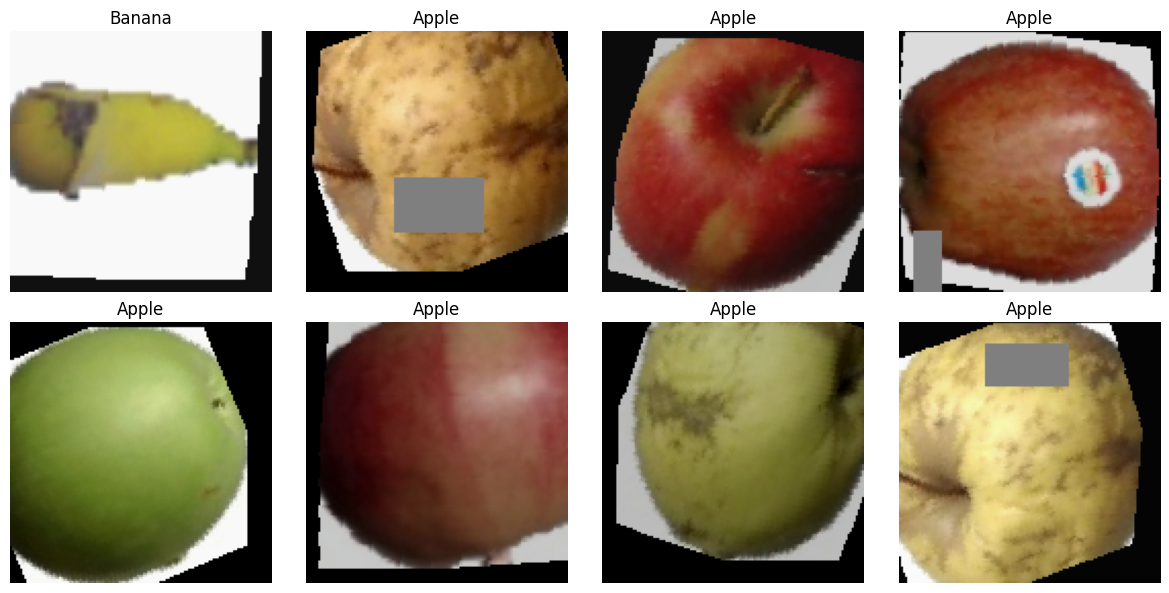

In [115]:
# ============================================================
# CELL 14: DISPLAY SAMPLE TRAINING IMAGES
# ============================================================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1, 2, 0).numpy()

    image = image * np.array(STD) + np.array(MEAN)
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(
        full_train_dataset.classes[labels[i]]
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [116]:
# ============================================================
# CELL 15: CNN MODEL
# ============================================================

class CNN(nn.Module):

    def __init__(self, num_classes=3):

        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNN(
    num_classes=3
).to(device)

print(model)
print("\nDevice:", device)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (

In [117]:
# ============================================================
# CELL 16: LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [118]:
# ============================================================
# CELL 17: TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = (
        100 * correct / total
    )

    return epoch_loss, epoch_accuracy

In [119]:
# ============================================================
# CELL 18: VALIDATION FUNCTION
# ============================================================

def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = (
        100 * correct / total
    )

    return epoch_loss, epoch_accuracy

In [120]:
# ============================================================
# CELL 19: TRAIN MODEL (with LR scheduling + early stopping)
# ============================================================

EPOCHS = 25
EARLY_STOP_PATIENCE = 6

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_accuracy = 0.0
epochs_no_improve = 0

BEST_MODEL_PATH = f"{MODEL_DIR}/210137.pth"

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        epochs_no_improve = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✓ Best model saved ({val_acc:.2f}%)")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch + 1} (no improvement for {EARLY_STOP_PATIENCE} epochs).")
        break

print("\nTraining completed.")
print("Best validation accuracy:", best_val_accuracy)


Epoch [1/25] Train Loss: 0.1703 | Train Acc: 93.60% | Val Loss: 0.1390 | Val Acc: 93.03% | LR: 0.001000
  ✓ Best model saved (93.03%)
Epoch [2/25] Train Loss: 0.1007 | Train Acc: 96.36% | Val Loss: 0.0476 | Val Acc: 98.56% | LR: 0.001000
  ✓ Best model saved (98.56%)
Epoch [3/25] Train Loss: 0.0946 | Train Acc: 96.54% | Val Loss: 0.0348 | Val Acc: 97.96% | LR: 0.001000
Epoch [4/25] Train Loss: 0.0885 | Train Acc: 96.73% | Val Loss: 0.2101 | Val Acc: 91.59% | LR: 0.001000
Epoch [5/25] Train Loss: 0.0732 | Train Acc: 97.37% | Val Loss: 0.3210 | Val Acc: 93.15% | LR: 0.001000
Epoch [6/25] Train Loss: 0.0882 | Train Acc: 96.97% | Val Loss: 0.0905 | Val Acc: 94.59% | LR: 0.001000
Epoch [7/25] Train Loss: 0.0718 | Train Acc: 97.42% | Val Loss: 0.0615 | Val Acc: 96.03% | LR: 0.000500
Epoch [8/25] Train Loss: 0.0574 | Train Acc: 97.86% | Val Loss: 0.0501 | Val Acc: 97.00% | LR: 0.000500

Early stopping at epoch 8 (no improvement for 6 epochs).

Training completed.
Best validation accuracy: 98.

In [121]:
# ============================================================
# CELL 20: LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


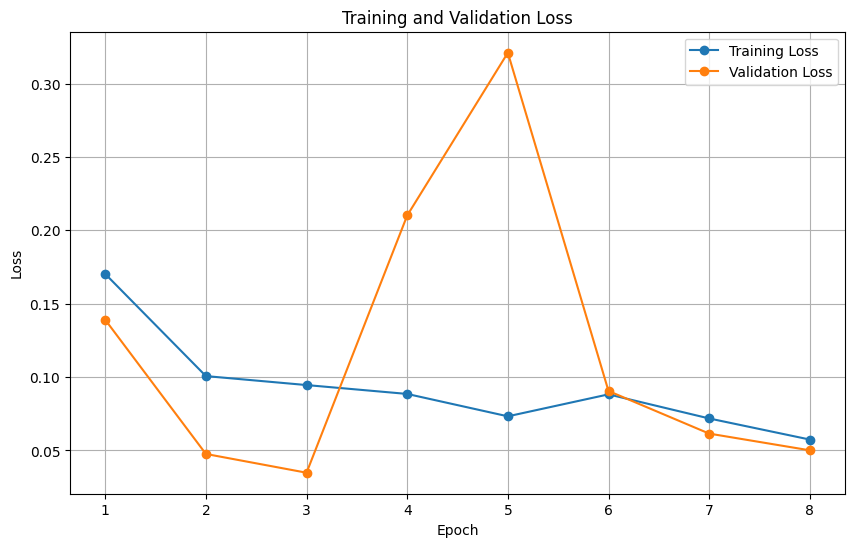

In [122]:
# ============================================================
# CELL 21: LOSS GRAPH
# ============================================================

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))

plt.plot(epochs_range, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

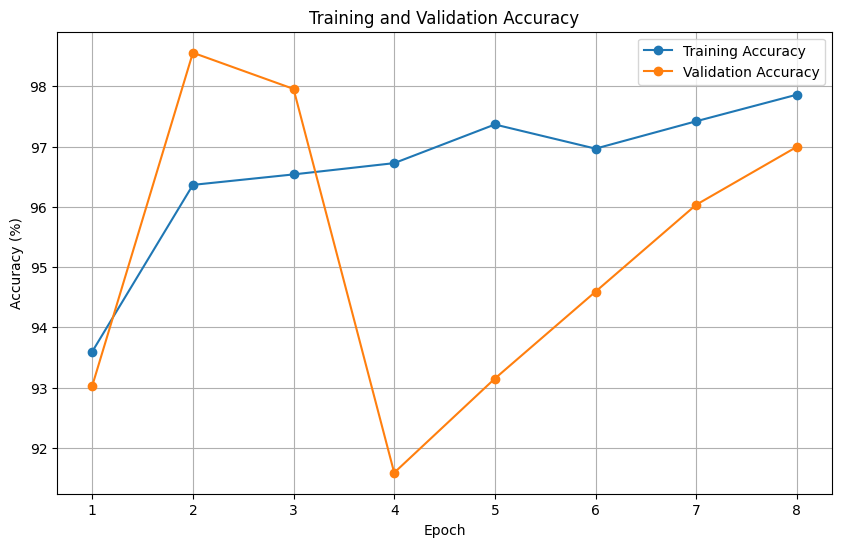

In [123]:
# ============================================================
# CELL 22: ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(epochs_range, history["train_acc"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [124]:
# ============================================================
# CELL 23: STANDARD TEST SET
# ============================================================

test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.0620
Test Accuracy: 97.84%


In [125]:
# ============================================================
# CELL 24: TEST PREDICTIONS
# ============================================================

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions generated.")

Predictions generated.


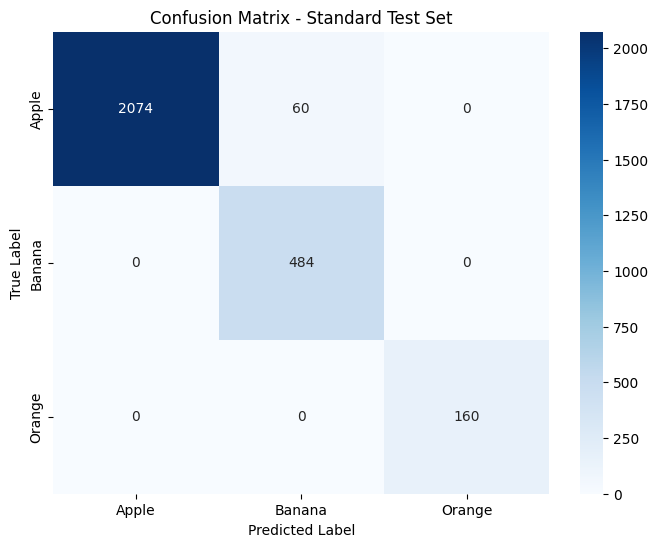

In [126]:
# ============================================================
# CELL 25: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Standard Test Set")

plt.show()

In [127]:
# ============================================================
# CELL 26: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

       Apple       1.00      0.97      0.99      2134
      Banana       0.89      1.00      0.94       484
      Orange       1.00      1.00      1.00       160

    accuracy                           0.98      2778
   macro avg       0.96      0.99      0.98      2778
weighted avg       0.98      0.98      0.98      2778



In [128]:
# ============================================================
# CELL 27: FIND INCORRECT PREDICTIONS
# ============================================================

incorrect_indices = np.where(all_labels != all_predictions)[0]

print("Incorrect predictions:", len(incorrect_indices))

Incorrect predictions: 60


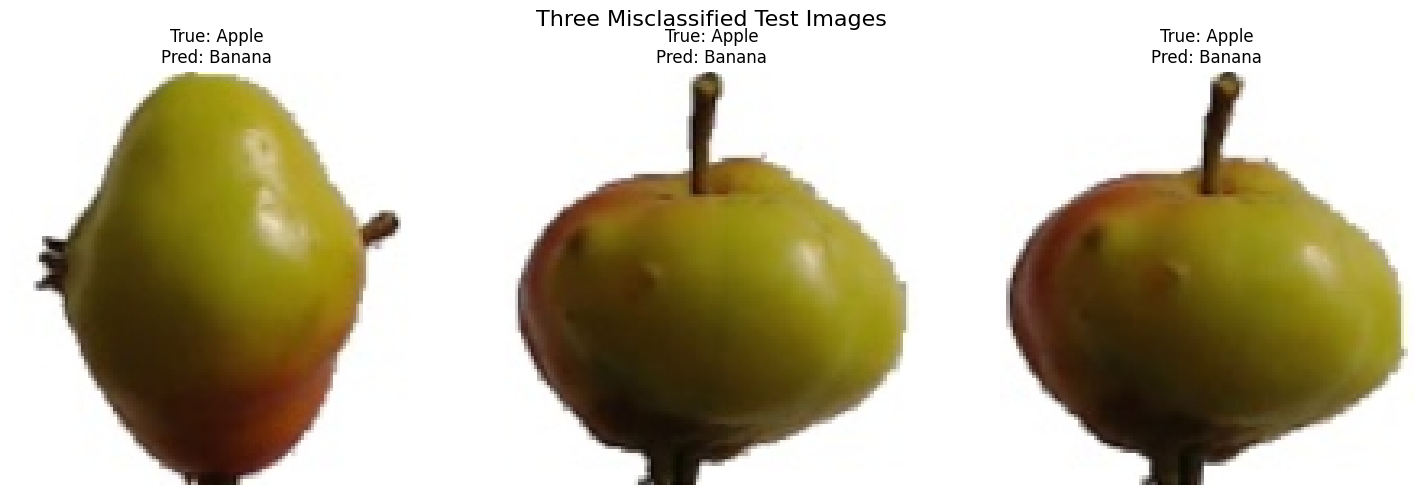

In [129]:
# ============================================================
# CELL 28: ERROR ANALYSIS
# ============================================================

if len(incorrect_indices) > 0:

    number_to_show = min(3, len(incorrect_indices))
    selected_indices = random.sample(list(incorrect_indices), number_to_show)

    fig, axes = plt.subplots(1, number_to_show, figsize=(15, 5))

    if number_to_show == 1:
        axes = [axes]

    for ax, idx in zip(axes, selected_indices):

        image, true_label = test_dataset[idx]

        image_display = image.permute(1, 2, 0).numpy()
        image_display = image_display * np.array(STD) + np.array(MEAN)
        image_display = np.clip(image_display, 0, 1)

        predicted_label = all_predictions[idx]

        ax.imshow(image_display)
        ax.set_title(
            f"True: {test_dataset.classes[true_label]}\n"
            f"Pred: {test_dataset.classes[predicted_label]}"
        )
        ax.axis("off")

    plt.suptitle("Three Misclassified Test Images", fontsize=16)
    plt.tight_layout()
    plt.show()

else:
    print("No incorrect predictions found.")

In [130]:
# ============================================================
# CELL 29: CUSTOM IMAGE PREDICTION
# ============================================================

LASS_NAMES = ["Apple", "Banana", "Orange"]

def predict_custom_image(image_path, model, transform, device):

    image = Image.open(image_path).convert("RGB")
    views = [image, ImageOps.mirror(image)]

    model.eval()
    probs_sum = None

    with torch.no_grad():
        for view in views:
            input_tensor = transform(view).unsqueeze(0).to(device)
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs

    probs_avg = probs_sum / len(views)
    confidence, predicted = torch.max(probs_avg, dim=1)

    predicted_class = CLASS_NAMES[predicted.item()]
    confidence_percentage = confidence.item() * 100

    return predicted_class, confidence_percentage

In [131]:
# ============================================================
# CELL 30: TEST ONE CUSTOM IMAGE
# ============================================================

# Redefine the function here to fix the NameError within this cell's scope
CLASS_NAMES = ["Apple", "Banana", "Orange"]

def predict_custom_image(image_path, model, transform, device):

    image = Image.open(image_path).convert("RGB")
    views = [image, ImageOps.mirror(image)]

    model.eval()
    probs_sum = None

    with torch.no_grad():
        for view in views:
            input_tensor = transform(view).unsqueeze(0).to(device)
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs

    probs_avg = probs_sum / len(views)
    confidence, predicted = torch.max(probs_avg, dim=1)

    predicted_class = CLASS_NAMES[predicted.item()]
    confidence_percentage = confidence.item() * 100

    return predicted_class, confidence_percentage


test_filename = custom_images[0]
test_image_path = os.path.join(PROCESSED_DATA_PATH, test_filename)

prediction, confidence = predict_custom_image(
    test_image_path, model, eval_transform, device
)

print("File:", test_filename)
print("Prediction:", prediction)
print(f"Confidence: {confidence:.2f}%")


File: apple1.jpeg
Prediction: Banana
Confidence: 96.41%


In [132]:
# ============================================================
# CELL 31: PREDICT ALL CUSTOM IMAGES
# ============================================================

custom_results = []

for filename in sorted(custom_images):

    image_path = os.path.join(PROCESSED_DATA_PATH, filename)

    prediction, confidence = predict_custom_image(
        image_path, model, eval_transform, device
    )

    custom_results.append({
        "filename": filename,
        "prediction": prediction,
        "confidence": confidence
    })

for result in custom_results:
    print(
        f"{result['filename']:20s} "
        f"\u2192 {result['prediction']:10s} "
        f"({result['confidence']:.2f}%)"
    )

apple1.jpeg          → Banana     (96.41%)
apple2.jpeg          → Apple      (99.99%)
apple3.jpeg          → Apple      (100.00%)
apple4.jpeg          → Apple      (99.98%)
banana1.jpeg         → Banana     (100.00%)
banana2.jpeg         → Banana     (100.00%)
banana3.jpeg         → Banana     (100.00%)
orange1.jpeg         → Apple      (59.46%)
orange2.jpeg         → Banana     (89.04%)
orange3.jpeg         → Banana     (84.39%)


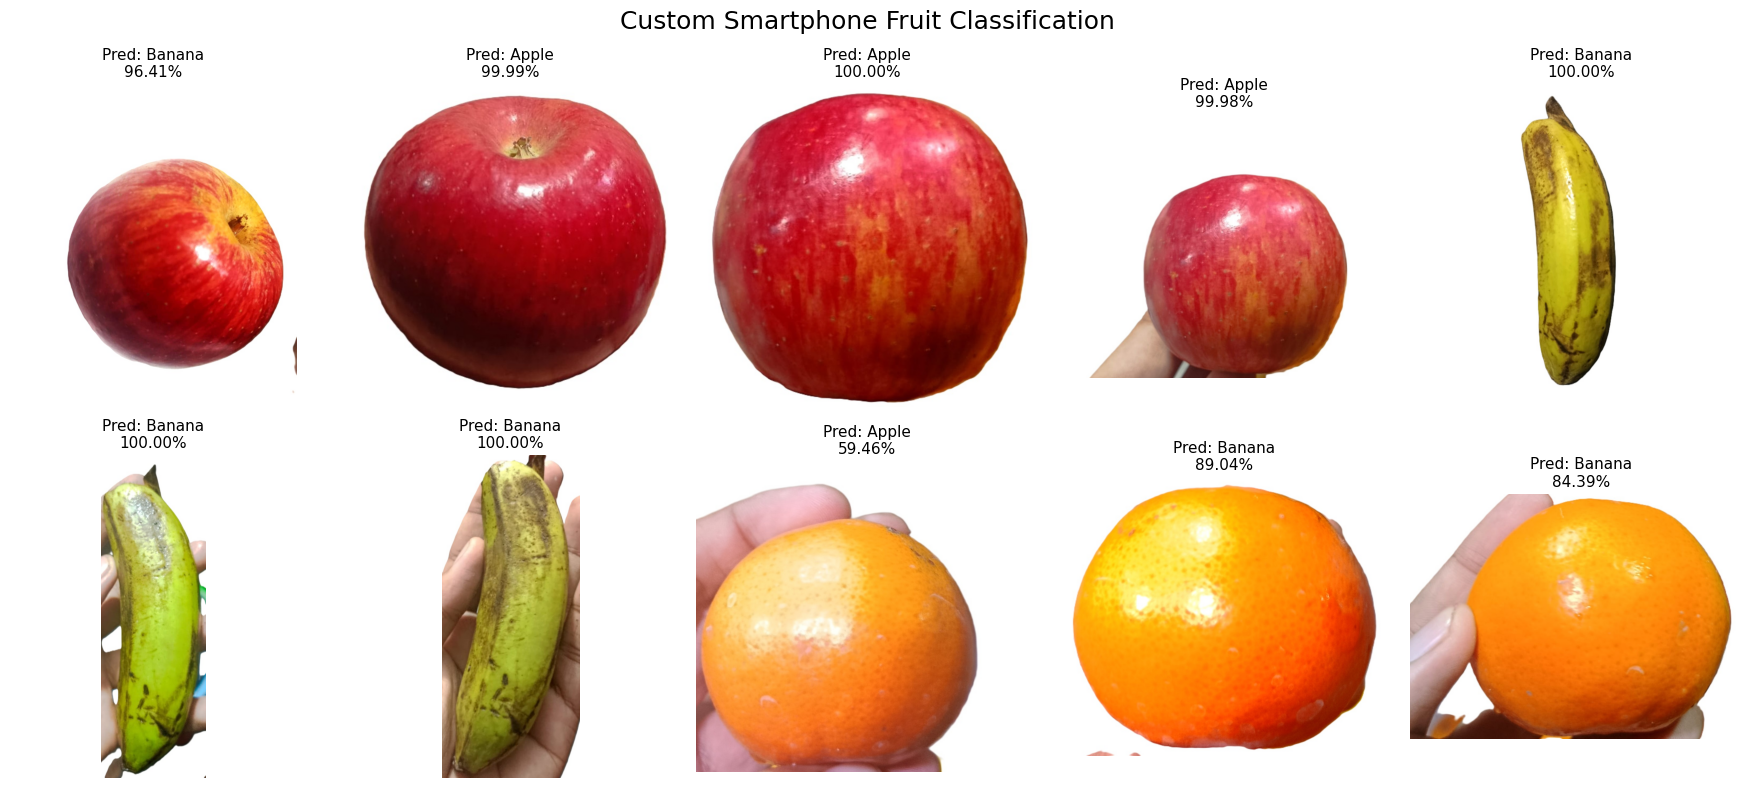

In [133]:
# ============================================================
# CELL 32: CUSTOM PREDICTION GALLERY
# ============================================================

num_images = len(custom_images)

columns = 5
rows = int(np.ceil(num_images / columns))

fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(18, 8)
)

axes = np.array(axes).reshape(-1)

for ax, result in zip(
    axes,
    custom_results
):

    image_path = os.path.join(
        CUSTOM_DATA_PATH,
        result["filename"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"Pred: {result['prediction']}\n"
        f"{result['confidence']:.2f}%",
        fontsize=11
    )

    ax.axis("off")


for ax in axes[num_images:]:
    ax.axis("off")


plt.suptitle(
    "Custom Smartphone Fruit Classification",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [134]:
# ============================================================
# CELL 33: SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = f"{MODEL_DIR}/210137.pth"

torch.save(
    model.state_dict(),
    FINAL_MODEL_PATH
)

print(
    "Model saved to:",
    FINAL_MODEL_PATH
)

Model saved to: /content/CNN-Project/model/210137.pth


In [135]:
# ============================================================
# CELL 34: VERIFY MODEL FILE
# ============================================================

if os.path.exists(FINAL_MODEL_PATH):

    file_size = os.path.getsize(
        FINAL_MODEL_PATH
    )

    print("✓ Model exists")
    print(
        f"✓ Size: {file_size / (1024 * 1024):.2f} MB"
    )

else:

    print("✗ Model file not found")

✓ Model exists
✓ Size: 2.94 MB
